In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

Welcome to JupyROOT 6.28/10


In [8]:
CUTEnoise = '/scratch/perry/CDMS/CUTE/R37/Processed/Releases/CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6/Noise/CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6_Filter_23231216_211119.root'
DMCnoise_old = '/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_pos50V_V05-09/Processed/Noise/Test_Filter_51250605_000000.root'
DMCnoise_new = '/project/6049244/share/SimData/DMC_SNOLAB_HV/Ge71_Kshell_pos50V_V05-09/Processed_fixedTemplates/Noise/Test_Filter_51250605_000000.root'

In [48]:
# Open the ROOT file
file = ROOT.TFile.Open(DMCnoise_old)
hist = file.Get(f'zip1/PFS1TemplateTime')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents_DMC_old = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
# Close the ROOT file
file.Close()
g1 = ROOT.TGraph(n_bins, bin_edges[:-1], bin_contents_DMC_old)

In [49]:
# Open the ROOT file
file = ROOT.TFile.Open(DMCnoise_new)
hist = file.Get(f'zip1/PFS1TemplateTime')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents_DMC_new = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
# Close the ROOT file
file.Close()
g2 = ROOT.TGraph(n_bins, bin_edges[:-1], bin_contents_DMC_new)

In [50]:
# Open the ROOT file
file = ROOT.TFile.Open(CUTEnoise)
hist = file.Get(f'zip1/PFS1TemplateTime')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents_CUTE = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
# Close the ROOT file
file.Close()
g3 = ROOT.TGraph(n_bins, bin_edges[:-1], np.roll(bin_contents_CUTE, 0))

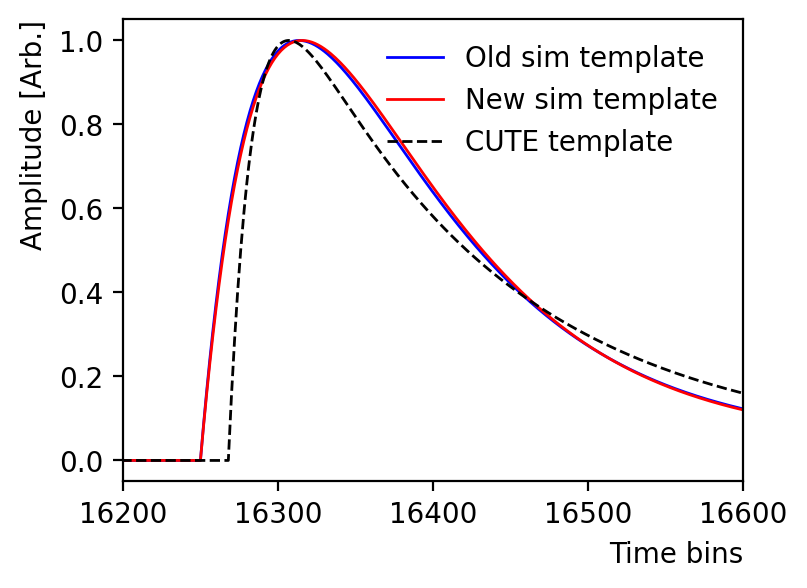

In [55]:
plt.figure(figsize=(4,3), dpi=200)

plt.plot(bin_contents_DMC_old, color = 'blue', lw = 1, label = 'Old sim template')
plt.plot(bin_contents_DMC_new, color = 'red', lw = 1, label = 'New sim template')
plt.plot(np.roll(bin_contents_CUTE, 20), color = 'black', lw = 1, ls = '--', label = 'CUTE template')

plt.xlim(16200, 16600)
plt.xlabel(r'Time bins', loc = 'right')
plt.ylabel('Amplitude [Arb.]', loc = 'top')
plt.legend(frameon=False)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


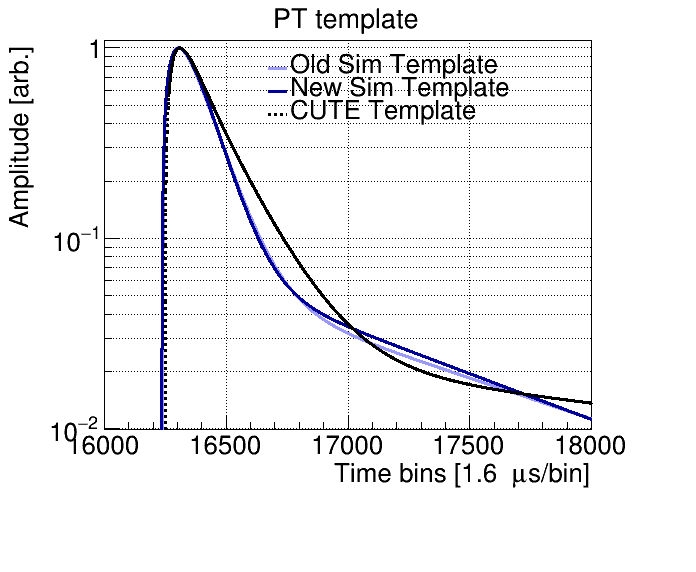

In [41]:
# Set style
g1.SetTitle("PT template;Time bins [1.6 #mus/bin];Amplitude [arb.]")
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(3)
g1.SetMarkerStyle(20)
g1.GetXaxis().SetRangeUser(16000, 18000)
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)

g2.SetLineColor(ROOT.kBlue+2)
g2.SetLineWidth(3)
#g2.SetLineStyle(2)

g3.SetLineColor(ROOT.kBlack)
g3.SetLineWidth(3)
g3.SetLineStyle(2)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.38, 0.78, 0.53, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, "Old Sim Template", "l")
legend.AddEntry(g2, "New Sim Template", "l")
legend.AddEntry(g3, "CUTE Template", "l")
legend.SetTextSize(0.05)

# Draw the graph with a line
c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.25)
c.SetRightMargin(0.15)
c.SetTopMargin(0.07)
g1.SetMinimum(1e-2)
g1.Draw("AL")  # A = axes, L = line (can also use "ALP" for points+line)
g2.Draw("SAME")
g3.Draw("SAME")
legend.Draw()
c.SetLogy()
c.SetGrid(1,1)
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


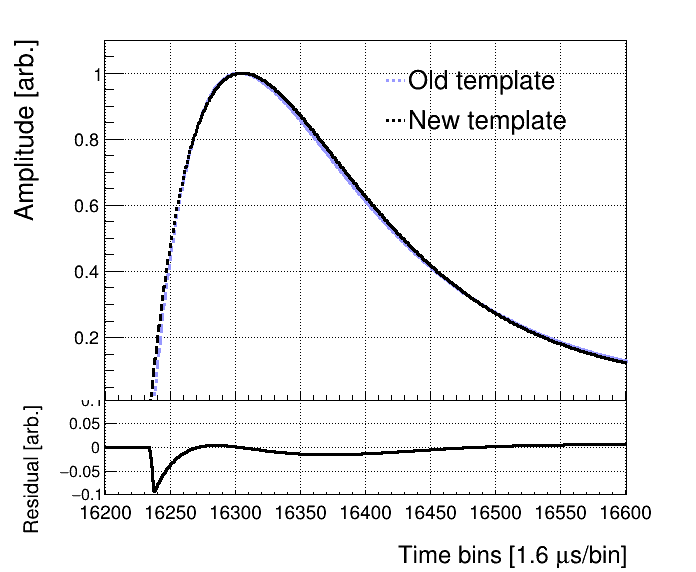

In [47]:
g1.GetXaxis().SetRangeUser(16200, 16600)
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(3)
g1.SetLineStyle(2)
g1.SetMarkerStyle(20)
g1.SetMarkerSize(0.3)
g1.SetMarkerColor(ROOT.kBlue-9)

g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.07)
g1.GetYaxis().SetTitleSize(0.07)
g1.GetYaxis().SetTitleOffset(1)
g1.SetMinimum(0.01)

g2.SetLineColor(ROOT.kBlack)
g2.SetLineWidth(3)
g2.SetLineStyle(2)
g2.SetMarkerStyle(20)
g2.SetMarkerSize(0.3)
g2.SetMarkerColor(ROOT.kBlack)

# --- Compute residuals (data - model) ---
residuals = bin_contents_DMC_old - np.roll(bin_contents_DMC_new, 0)
g_res = ROOT.TGraph(n_bins, bin_edges[:-1], residuals)
g_res.GetXaxis().SetRangeUser(16200, 16600)
g_res.SetLineWidth(3)
g_res.SetMarkerColor(ROOT.kBlack)
g_res.SetLineColor(ROOT.kBlack)
g_res.SetMarkerStyle(20)
g_res.SetMarkerSize(0.3)

# --- Canvas and pads ---
c = ROOT.TCanvas("c", "c", 700, 600)

pad1 = ROOT.TPad("pad1", "Top pad", 0, 0.3, 1, 1.0)
pad2 = ROOT.TPad("pad2", "Bottom pad", 0, 0.0, 1, 0.3)

pad1.SetBottomMargin(0)    # remove x labels on main plot
pad1.SetLeftMargin(0.15)
pad2.SetTopMargin(0)
pad2.SetBottomMargin(0.45)
pad2.SetLeftMargin(0.15)

pad1.Draw()
pad2.Draw()

# --- Top pad: scatter plots ---
pad1.cd()
g1.SetTitle(";Time bins [1.6 #mus/bin];Amplitude [arb.]")
g1.Draw("AL")        # A = axes, P = points
g2.Draw("L SAME")
pad1.SetGrid(1,1)

# Add legend
legend = ROOT.TLegend(0.55, 0.65, 0.7, 0.85)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(g1, "Old template", "l")
legend.AddEntry(g2, "New template", "l")
legend.SetTextSize(0.07)
legend.Draw()

# --- Bottom pad: residual plot ---
pad2.cd()
g_res.SetTitle(";Time bins [1.6 #mus/bin];Residual [arb.]")
g_res.GetXaxis().SetLabelOffset(0.05)
g_res.SetMinimum(-0.1)
g_res.SetMaximum(0.1)
g_res.Draw("AL")
ROOT.gPad.Update()
g_res.GetYaxis().SetNdivisions(105)
pad2.SetGrid(1,1)

# Format axes for residuals
g_res.GetXaxis().SetTitleSize(0.15)
g_res.GetXaxis().SetLabelSize(0.12)
g_res.GetYaxis().SetTitleSize(0.13)
g_res.GetYaxis().SetLabelSize(0.10)
g_res.GetYaxis().SetTitleOffset(0.5)
g_res.GetXaxis().SetTitleOffset(1.5)

c.cd()
c.Update()
c.Draw()